In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from tqdm import tqdm
from PIL import Image
#
import torch
import cv2
import ultralytics
from ultralytics import YOLO
from ultralytics.cfg import get_cfg

import yaml

# Процесс обучение YOLO на пользовательском наборе данных

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.is_available()}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'count: {torch.cuda.device_count()}')
    print(f'index: {torch.cuda.current_device()}')
    print(f'name: {torch.cuda.get_device_name(0)}')
else:
    print('Nvidia GPU отсутствует или PyTorch не установлен для CUDA')

GPU: True
CUDA version: 12.6
count: 1
index: 0
name: NVIDIA GeForce RTX 4060


In [5]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'data')

biscuit_dir = os.path.join(data_dir, 'Circle_Biscuit')
print(biscuit_dir)
print()
print('В ней находятся:')
print(os.listdir(biscuit_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit

В ней находятся:
['data.yaml', 'test', 'train', 'valid']


## 1. Подготавливаем путь к набору данных

In [6]:
# Подготавливаем абсолютный путь к файлу настроек 'yaml' набора данных 'Circle Biscuit'
path_to_yaml = os.path.join(biscuit_dir, 'data.yaml')
print(path_to_yaml)

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\data.yaml


In [7]:
# Открываем 'yaml' файл для набора данных 'Circle Biscuit'
with open(path_to_yaml, "r") as file:
    loaded_data = yaml.safe_load(file)  # Словарь, который хранит:
                                        # {'train': '../train/images', 
                                        #  'val': '../valid/images', 
                                        #  'test': '../test/images', 
                                        #  'nc': 2, 
                                        #  'names': ['broken biscuit', 'intact biscuit']}

# Check point
print('train: {0}'.format(loaded_data['train']))
print('val: {0}'.format(loaded_data['val']))
print('test: {0}'.format(loaded_data['test']))
print()
print('nc: {0}'.format(loaded_data['nc']))
print('names: {0}'.format(loaded_data['names']))

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['broken biscuit', 'intact biscuit']


## 2.  Обучаем YOLO

In [8]:
yolo_project_path = 'YOLO_Circle_Biscuit'

In [9]:
# Подготавливаем модель
# model = YOLO('yolo12l.pt')
# model = YOLO('yolo11l.pt')
# model = YOLO('yolov10l.pt')
# model = YOLO('yolov9t.pt')
#model = YOLO('yolov8n.pt')
model = YOLO('yolov8l.pt')


# Доступные модели и их отличия:
# https://docs.ultralytics.com/models

100%|█████████████████████████████████████████████████████████████████████████████| 83.7M/83.7M [00:12<00:00, 7.08MB/s]


In [10]:
# Смотрим на доступные аргументы
config = get_cfg()  
#print(config)

# Детальная информация по аргументам:
# https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
# https://docs.ultralytics.com/modes/predict/#inference-arguments

In [11]:
# Устанавливаем аргумент 'cache=None', чтобы не выделять на диске 'C' огромный объём памяти
# В этом случае, обучение будет проходить без кэширования изображений

# Запускаем обучение, предварительно настроив аргументы
results = model.train(
    task='detect',      # Задача, которая решается - рапознавание
    mode='train',       # Режим для запуска YOLO - обучение
    data=path_to_yaml,  # Путь к файлу настроек 'yaml' набора данных.
                        # В папке с файлом настроек 'yaml' должны находится папки: 'test', 'train' и 'valid'.
                        # В каждой из этих трех папок расположены еще по две папки: 'images' и 'labels'
    
    epochs=100,         # Количество эпох для обучения
    batch=4,            # Размер пакета для 1 итерации
    cache=None,         # Кэширование изображений
    #device='cpu',      # "cpu" - обучение на CPU, 0 - обучение на GPU
    device=0,
    patience=50,        # Период ожидания - эпохи, при отсутствии улучшения,
                        # для досрочного прекращения обучения
    lr0=1e-3,           # Начальное значение скорости обучения
    lrf=0.01,           # Конечное значение скорости обучения (lr0 * lrf)
    
    imgsz=640,          # Размер, к которому будут приведены изображения
    hsv_h=0.015,        # Аугментация цветовым тоном (hue adjustment)
    hsv_s=0.7,          # Аугментация насыщенностью (saturation adjustment)
    hsv_v=0.4,          # Аугментация яркостью (brightness adjustment)
    degrees=10,         # Аугментация вращением (rotation)
    scale=0.25,         # Аугментация масштабированием (scale)
    shear=8,            # Аугментация сдвигом (shear)
    perspective=0.001,  # Аугментация проекцией (perspective)
    flipud=0.5,         # Аугментация отражением по вертикали (Up-Down)
    fliplr=0.5,         # Аугментация отражение по горизонтали (Left-Right)

    save=True,          # Сохранять результаты обучения
    verbose=True,       # Отображать подробный ход обучения
    project=yolo_project_path,  # Директория для проекта
    name='train'        # Поддиректории проекта для каждого запуска обучения
)


# Доступные аргументы и их значения по умолчанию:
# https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.134  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=None, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosa

100%|█████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 8.23MB/s]


AMP: checks passed 
train: Fast image access  (ping: 0.00.0 ms, read: 452.4207.5 MB/s, size: 27.0 KB)


train: Scanning E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\train\la


val: Fast image access  (ping: 0.00.0 ms, read: 424.3149.4 MB/s, size: 26.1 KB)


...

     93/100      3.26G      1.102      0.738      1.532          5        640: 100%|██████████| 20/20 [00:03<00:00,  6.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<0

                   all         18         62      0.935      0.927      0.962      0.434
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 43, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



93 epochs completed in 0.162 hours.
Optimizer stripped from YOLO_Circle_Biscuit\train\weights\last.pt, 87.7MB
Optimizer stripped from YOLO_Circle_Biscuit\train\weights\best.pt, 87.7MB

Validating YOLO_Circle_Biscuit\train\weights\best.pt...
Ultralytics 8.3.134  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
Model summary (fused): 112 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<0


                   all         18         62      0.886      0.903      0.948      0.533
        broken biscuit         14         37      0.772      0.838        0.9       0.52
        intact biscuit         13         25          1      0.968      0.995      0.546
Speed: 0.2ms preprocess, 18.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to YOLO_Circle_Biscuit\train


In [12]:
# Извлекаем путь к директориии с текущим результатом обучения
save_dir = results.save_dir
# Check point
print(save_dir)
print()
print(f'В директории: "{save_dir}"\nс текущими результатами обучения находятся:')
print()
print(os.listdir(save_dir))

YOLO_Circle_Biscuit\train

В директории: "YOLO_Circle_Biscuit\train"
с текущими результатами обучения находятся:

['args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'labels.jpg', 'labels_correlogram.jpg', 'PR_curve.png', 'P_curve.png', 'results.csv', 'results.png', 'R_curve.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch1800.jpg', 'train_batch1801.jpg', 'train_batch1802.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


In [13]:
# Вручную подготавливаем абсолютный путь к директории с результатами обучения
path_to_train = os.path.join(os.getcwd(), save_dir)

# Check point
print(f'В директории: "{path_to_train}"\nс текущими результатами обучения находятся:')
print()
print(os.listdir(path_to_train))

В директории: "E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train"
с текущими результатами обучения находятся:

['args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'labels.jpg', 'labels_correlogram.jpg', 'PR_curve.png', 'P_curve.png', 'results.csv', 'results.png', 'R_curve.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch1800.jpg', 'train_batch1801.jpg', 'train_batch1802.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


## 3. Продолжаем обучение после прерывания

In [14]:
# Подготавливаем абсолютный путь к директории где находятся веcовые коэффициенты
path_to_weights = os.path.abspath(os.path.join(path_to_train, 'weights'))

# Check point
print(path_to_train)
print()
print(f'В директории "{path_to_weights}" с текущими результатами обучения находятся:')
print(os.listdir(path_to_weights))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train

В директории "E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train\weights" с текущими результатами обучения находятся:
['best.pt', 'last.pt']


In [15]:
# Подготавливаем абсолютный путь к последним весовым коэффициентам
path_to_last_weights = os.path.join(path_to_weights, 'last.pt')
print(path_to_last_weights)

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train\weights\last.pt


In [16]:
# Подготавливаем модель, загружая последние весовые коэффициенты
model = YOLO(path_to_last_weights)

In [17]:
# Запускаем продолжение обучения
'''
results = model.train(
    # Продолжаем обучение со всеми ранее сделанными настройками
    resume=True
)
'''

results = model.train(
    task='detect', mode='train', data=path_to_yaml, epochs=100, batch=4, cache=None, device=0, patience=50, lr0=1e-3, lrf=0.01,
    imgsz=640, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=10, scale=0.25, shear=8, perspective=0.001, flipud=0.5, fliplr=0.5,
    save=True, verbose=True, project=yolo_project_path, name='train'
)

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.134  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=None, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=E:\Progi\PythonProg\OtusML\Profe

train: Scanning E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\train\la


val: Fast image access  (ping: 0.00.0 ms, read: 267.642.2 MB/s, size: 26.1 KB)


val: Scanning E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\valid\labe


Plotting labels to YOLO_Circle_Biscuit\train2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to YOLO_Circle_Biscuit\train2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     63/100       3.3G      1.274     0.9121      1.638          8        640: 100%|██████████| 20/20 [00:03<00:00,  5.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<0


                   all         18         62      0.901       0.97      0.948      0.424
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 13, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

63 epochs completed in 0.107 hours.
Optimizer stripped from YOLO_Circle_Biscuit\train2\weights\last.pt, 87.6MB
Optimizer stripped from YOLO_Circle_Biscuit\train2\weights\best.pt, 87.6MB

Validating YOLO_Circle_Biscuit\train2\weights\best.pt...
Ultralytics 8.3.134  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
Model summary (fused): 112 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<0


                   all         18         62      0.814      0.919      0.915      0.531
        broken biscuit         14         37      0.771      0.838      0.835      0.528
        intact biscuit         13         25      0.856          1      0.995      0.534
Speed: 0.6ms preprocess, 15.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to YOLO_Circle_Biscuit\train2


## 4. Запускаем валидацию на валидационной выборке

In [18]:
# Извлекаем путь к директориии с текущим результатом обучения
save_dir2 = results.save_dir
# Check point
print(save_dir2)
print()
print(f'В директории: "{save_dir2}"\nс текущими результатами обучения находятся:')
print()
print(os.listdir(save_dir2))

YOLO_Circle_Biscuit\train2

В директории: "YOLO_Circle_Biscuit\train2"
с текущими результатами обучения находятся:

['args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'labels.jpg', 'labels_correlogram.jpg', 'PR_curve.png', 'P_curve.png', 'results.csv', 'results.png', 'R_curve.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


In [19]:
# Вручную подготавливаем абсолютный путь к директории с результатами обучения
path_to_train2 = os.path.join(os.getcwd(), save_dir2)

# Check point
print(f'В директории: "{path_to_train2}"\nс текущими результатами обучения находятся:')
print()
print(os.listdir(path_to_train))

В директории: "E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train2"
с текущими результатами обучения находятся:

['args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'labels.jpg', 'labels_correlogram.jpg', 'PR_curve.png', 'P_curve.png', 'results.csv', 'results.png', 'R_curve.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch1800.jpg', 'train_batch1801.jpg', 'train_batch1802.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


In [20]:
# Подготавливаем абсолютный путь к директории где находятся веcовые коэффициенты
path_to_weights2 = os.path.abspath(os.path.join(path_to_train2, 'weights'))

# Подготавливаем абсолютный путь к наилучшим весовым коэффициентам
path_to_best_weights2 = os.path.join(path_to_weights2, 'best.pt')

# Check point
print(path_to_train2)
print(path_to_weights2)
print()
print(f'В директории "{path_to_weights2}" с текущими результатами обучения находятся:')
print(os.listdir(path_to_weights2))
print()
print(path_to_best_weights2)

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train2
E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train2\weights

В директории "E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train2\weights" с текущими результатами обучения находятся:
['best.pt', 'last.pt']

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\train2\weights\best.pt


In [21]:
# Подготавливаем модель
model = YOLO(path_to_best_weights2)

In [22]:
# Запускаем валидацию на валидационной выборке
metrics = model.val(
    split='val',  # Валидация на валидационной выборке 'val'
    project=yolo_project_path,  # Директория для проекта
    name='valid'  # Поддиректории проекта для каждого запуска валидации
)

Ultralytics 8.3.134  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
Model summary (fused): 112 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 533.672.3 MB/s, size: 22.4 KB)


val: Scanning E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\Circle_Biscuit\valid\labe
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<0


                   all         18         62      0.814      0.919      0.915      0.527
        broken biscuit         14         37      0.772      0.838      0.835      0.526
        intact biscuit         13         25      0.857          1      0.995      0.529
Speed: 0.8ms preprocess, 37.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to YOLO_Circle_Biscuit\valid


In [23]:
# Извлекаем путь к директориии с текущим результатом валидации
val_save_dir = metrics.save_dir

# Check point
print(val_save_dir)
print()
print(f'В директории: "{val_save_dir}"\nс текущими результатами валидации находятся:')
print()
print(os.listdir(val_save_dir))

YOLO_Circle_Biscuit\valid

В директории: "YOLO_Circle_Biscuit\valid"
с текущими результатами валидации находятся:

['confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg']


In [24]:
# Вручную подготавливаем абсолютный путь к директории с результатами валидации
path_to_valid = os.path.join(os.getcwd(), val_save_dir)

# Check point
print(f'В директории: "{path_to_valid}"\nс текущими результатами обучения находятся:')
print()
print(os.listdir(path_to_valid))
valid_images = os.listdir(path_to_valid)

В директории: "E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\YOLO_Circle_Biscuit\valid"
с текущими результатами обучения находятся:

['confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg']


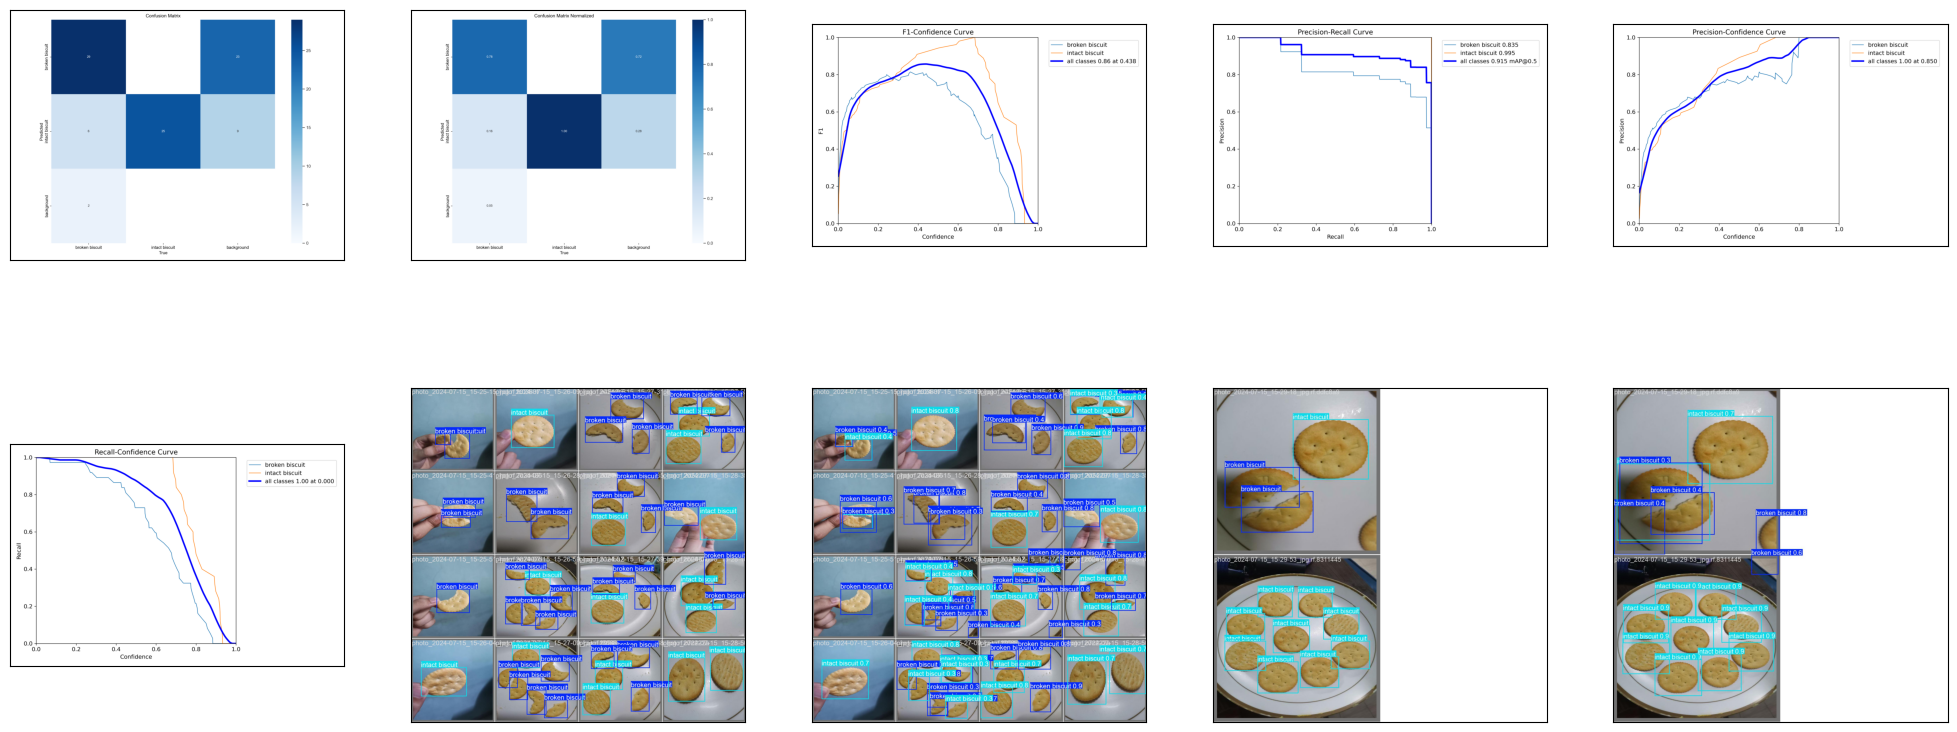

In [32]:
plt.figure(figsize=(25, 10), dpi=100)
i = 0
for img_name in valid_images:
    i += 1
    ax = plt.subplot(2, 5, i)
    path_to_img = os.path.join(path_to_valid, img_name)
    valid_img = Image.open(path_to_img).convert('RGB')
    plt.imshow(valid_img)
    plt.xticks([])
    plt.yticks([])

#plt.subplots_adjust(wspace=0.05, hspace=-0.01)
plt.show();